# SHAP vs program score vs perturbation score visualisation analyses

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
})

# Helper functions

In [2]:
source("../scripts/plotting.R")

# Discovery cohort

## Load data

### Perturbation scores

In [ ]:
meld.stats <- set_names(c("Early", "Late")) %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### GEP usages

In [ ]:
gep.usage <- set_names(c("B", "DC", "Mono", "NK", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`
New names:
* `` -> `...1`


### SHAP values

In [ ]:
shap <- set_names(c("B", "T")) %>%
  map(
    .f = function(x) {
      set_names("Late") %>%
        map(
          .f = function(y) {
            mat <- read.table(
              file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/shap/{x}/{y}.tsv"),
              sep = "\t",
              header = TRUE,
              row.names = 1,
              check.names = FALSE
            )
            return(mat)
          }
        )
    }
  )

## B cells

In [15]:
cell.type <- "B"
cond <- "Late"

usage.long <- gep.usage[[cell.type]] %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "usage")

shap.long <- shap[[cell.type]][[cond]] %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "shap_value")

meld <- meld.stats[[cond]] %>%
  rownames_to_column("barcode") %>%
  select(barcode, z)

data <- usage.long %>%
  full_join(shap.long, by = c("barcode", "program")) %>%
  left_join(meld, by = "barcode") %>%
  filter(!grepl(pattern = "Artefact|Contamination|Housekeeping", x = program))

In [16]:
data.summary <- map_dfr(
  .x = unique(data$program),
  .f = function(x,
                threshold = 0.2) {
    I <- data %>% filter(program == x & usage > threshold)
    mean.abs.shap <- mean(abs(I$shap_value))
    mean.perturbation <- mean(I$z)
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
)

In [17]:
data.summary

program,mean_abs_shap,mean_perturbation,program_effect_score
<chr>,<dbl>,<dbl>,<dbl>
Mature Naive (BACH2/SELL/IL4R),3.4155802,-23.871669,-81.535603
Homeostatic Memory (BANK1/AIM2/CD27),7.6395877,-35.501939,-271.220177
Survival Signalling (BCL2),5.0192431,-5.491045,-27.560888
Transitional Naive (MME/CD9/CD38),11.3738836,4.197527,47.742184
Primed Memory (IL2RA/TOX),4.3876534,-33.421907,-146.643743
Activated Memory (CD80/FAS),0.9494284,-23.341198,-22.160796
Activation Signalling (IER2/CD69/CD83),0.6093805,-22.215323,-13.537585
Atypical Memory (ITGAX/TBX21/FCRL5),2.3339695,-31.680373,-73.941024
IgA+ ASC (IGHA1/JCHAIN/MZB1),2.2260909,-2.227579,-4.958794


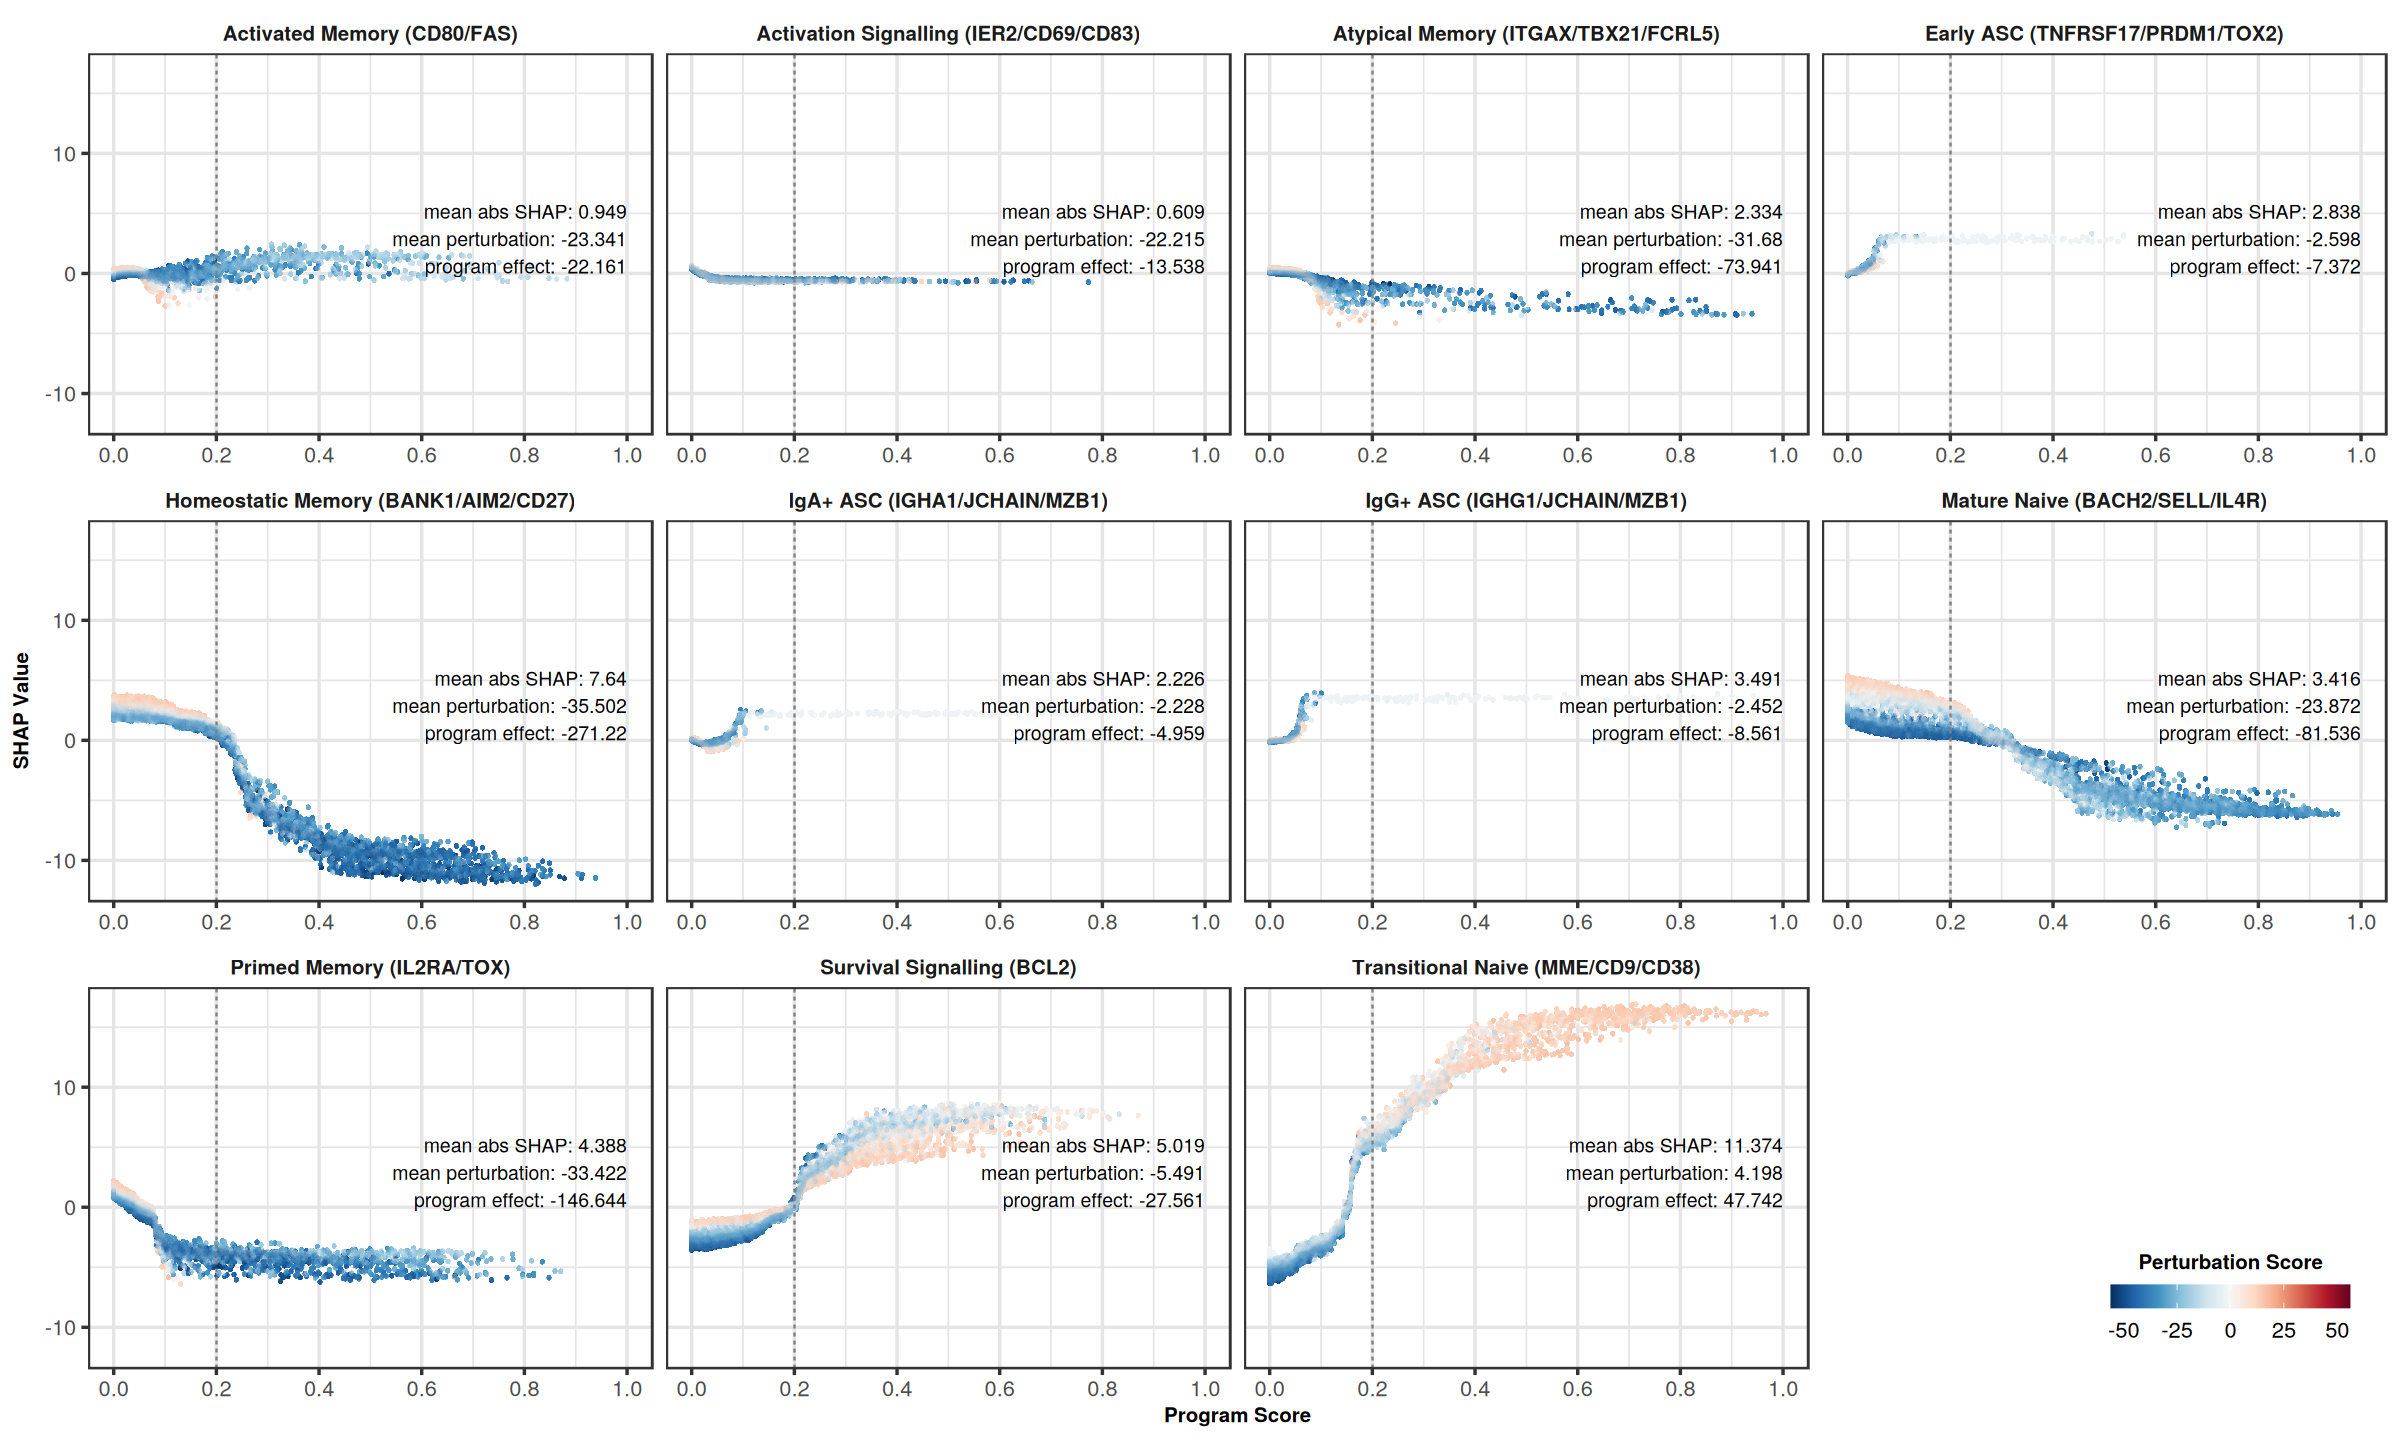

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 12)

plot <- ggplot(data = data) +
  scattermore::geom_scattermore(mapping = aes(x = usage, y = shap_value, colour = z), pointsize = 10, alpha = 1, pixels = c(2048, 1229)) +
  geom_text(
    data = data.summary %>% mutate(label = paste0("mean abs SHAP: ", round(mean_abs_shap, 3), "\nmean perturbation: ", round(mean_perturbation, 3), "\nprogram effect: ", round(program_effect_score, 3))),
    mapping = aes(label = label),
    x = 1,
    y = 0,
    hjust = 1,
    vjust = 0,
    size = 4
  ) +
  geom_vline(xintercept = 0.2, linetype = "dashed", colour = "grey50") +
  scale_x_continuous(breaks = seq(0, 1, by = 0.2), limits = c(0, 1)) +
  scale_colour_gradientn(limits = max(abs(data$z)) * c(-1, 1), colours = rev(pals::brewer.rdbu(100))) +
  guides(colour = guide_colourbar(direction = "horizontal", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  facet_wrap(~program, ncol = 4, scales = "free_x") +
  labs(x = "Program Score", y = "SHAP Value", colour = "Perturbation Score") +
  theme_custom() +
  inset.legend(location = "bottomright") + 
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(size = 12, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 12, face = "bold"),
    strip.background = element_blank(),
    panel.grid = element_line(colour = "grey90")
  )

plot

ggsave(
  plot = plot,
  filename = glue::glue("../results/plots/cohort_treatment_naive_{cell.type}_{cond}_shap_program_perturbation.pdf"),
  width = 20,
  height = 12,
  units = "in",
  device = cairo_pdf
)

## T cells

In [11]:
cell.type <- "T"
cond <- "Late"

usage.long <- gep.usage[[cell.type]] %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "usage")

shap.long <- shap[[cell.type]][[cond]] %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "shap_value")

meld <- meld.stats[[cond]] %>%
  rownames_to_column("barcode") %>%
  select(barcode, z)

data <- usage.long %>%
  full_join(shap.long, by = c("barcode", "program")) %>%
  left_join(meld, by = "barcode") %>%
  filter(!grepl(pattern = "Artefact|Contamination|Housekeeping", x = program))

In [12]:
data.summary <- map_dfr(
  .x = unique(data$program),
  .f = function(x,
                threshold = 0.2) {
    I <- data %>% filter(program == x & usage > threshold)
    mean.abs.shap <- mean(abs(I$shap_value))
    mean.perturbation <- mean(I$z)
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
)

In [13]:
data.summary

program,mean_abs_shap,mean_perturbation,program_effect_score
<chr>,<dbl>,<dbl>,<dbl>
Naive CD4 (CCR7/TCF7/FOXP1),1.599184754,6.3834896,1.020838e+01
Immune Synapse Assembly (ACTB/THEMIS/SKAP1),0.154838788,2.2306446,3.453903e-01
Resting Naive (BCL11B/PDE7A),0.342720238,4.8519473,1.662861e+00
Naive/Central Memory CD8 (CD8A/CD8B/LEF1),0.565042675,0.7954436,4.494596e-01
Precursor Memory (CD38/IRF4/FOXP1),1.224326335,5.9124840,7.238810e+00
Survival Signalling (BCL2),3.240992427,9.9737734,3.232492e+01
Central Memory CD4 (IL7R/ITGB1/RORA),0.829437391,-2.5473939,-2.112904e+00
Activation Signalling (NFKB1/REL/NR4A3),1.026227739,-5.6718494,-5.820609e+00
Tfh-like (ICOS/MAF/TOX2),1.257807886,-4.2098849,-5.295226e+00


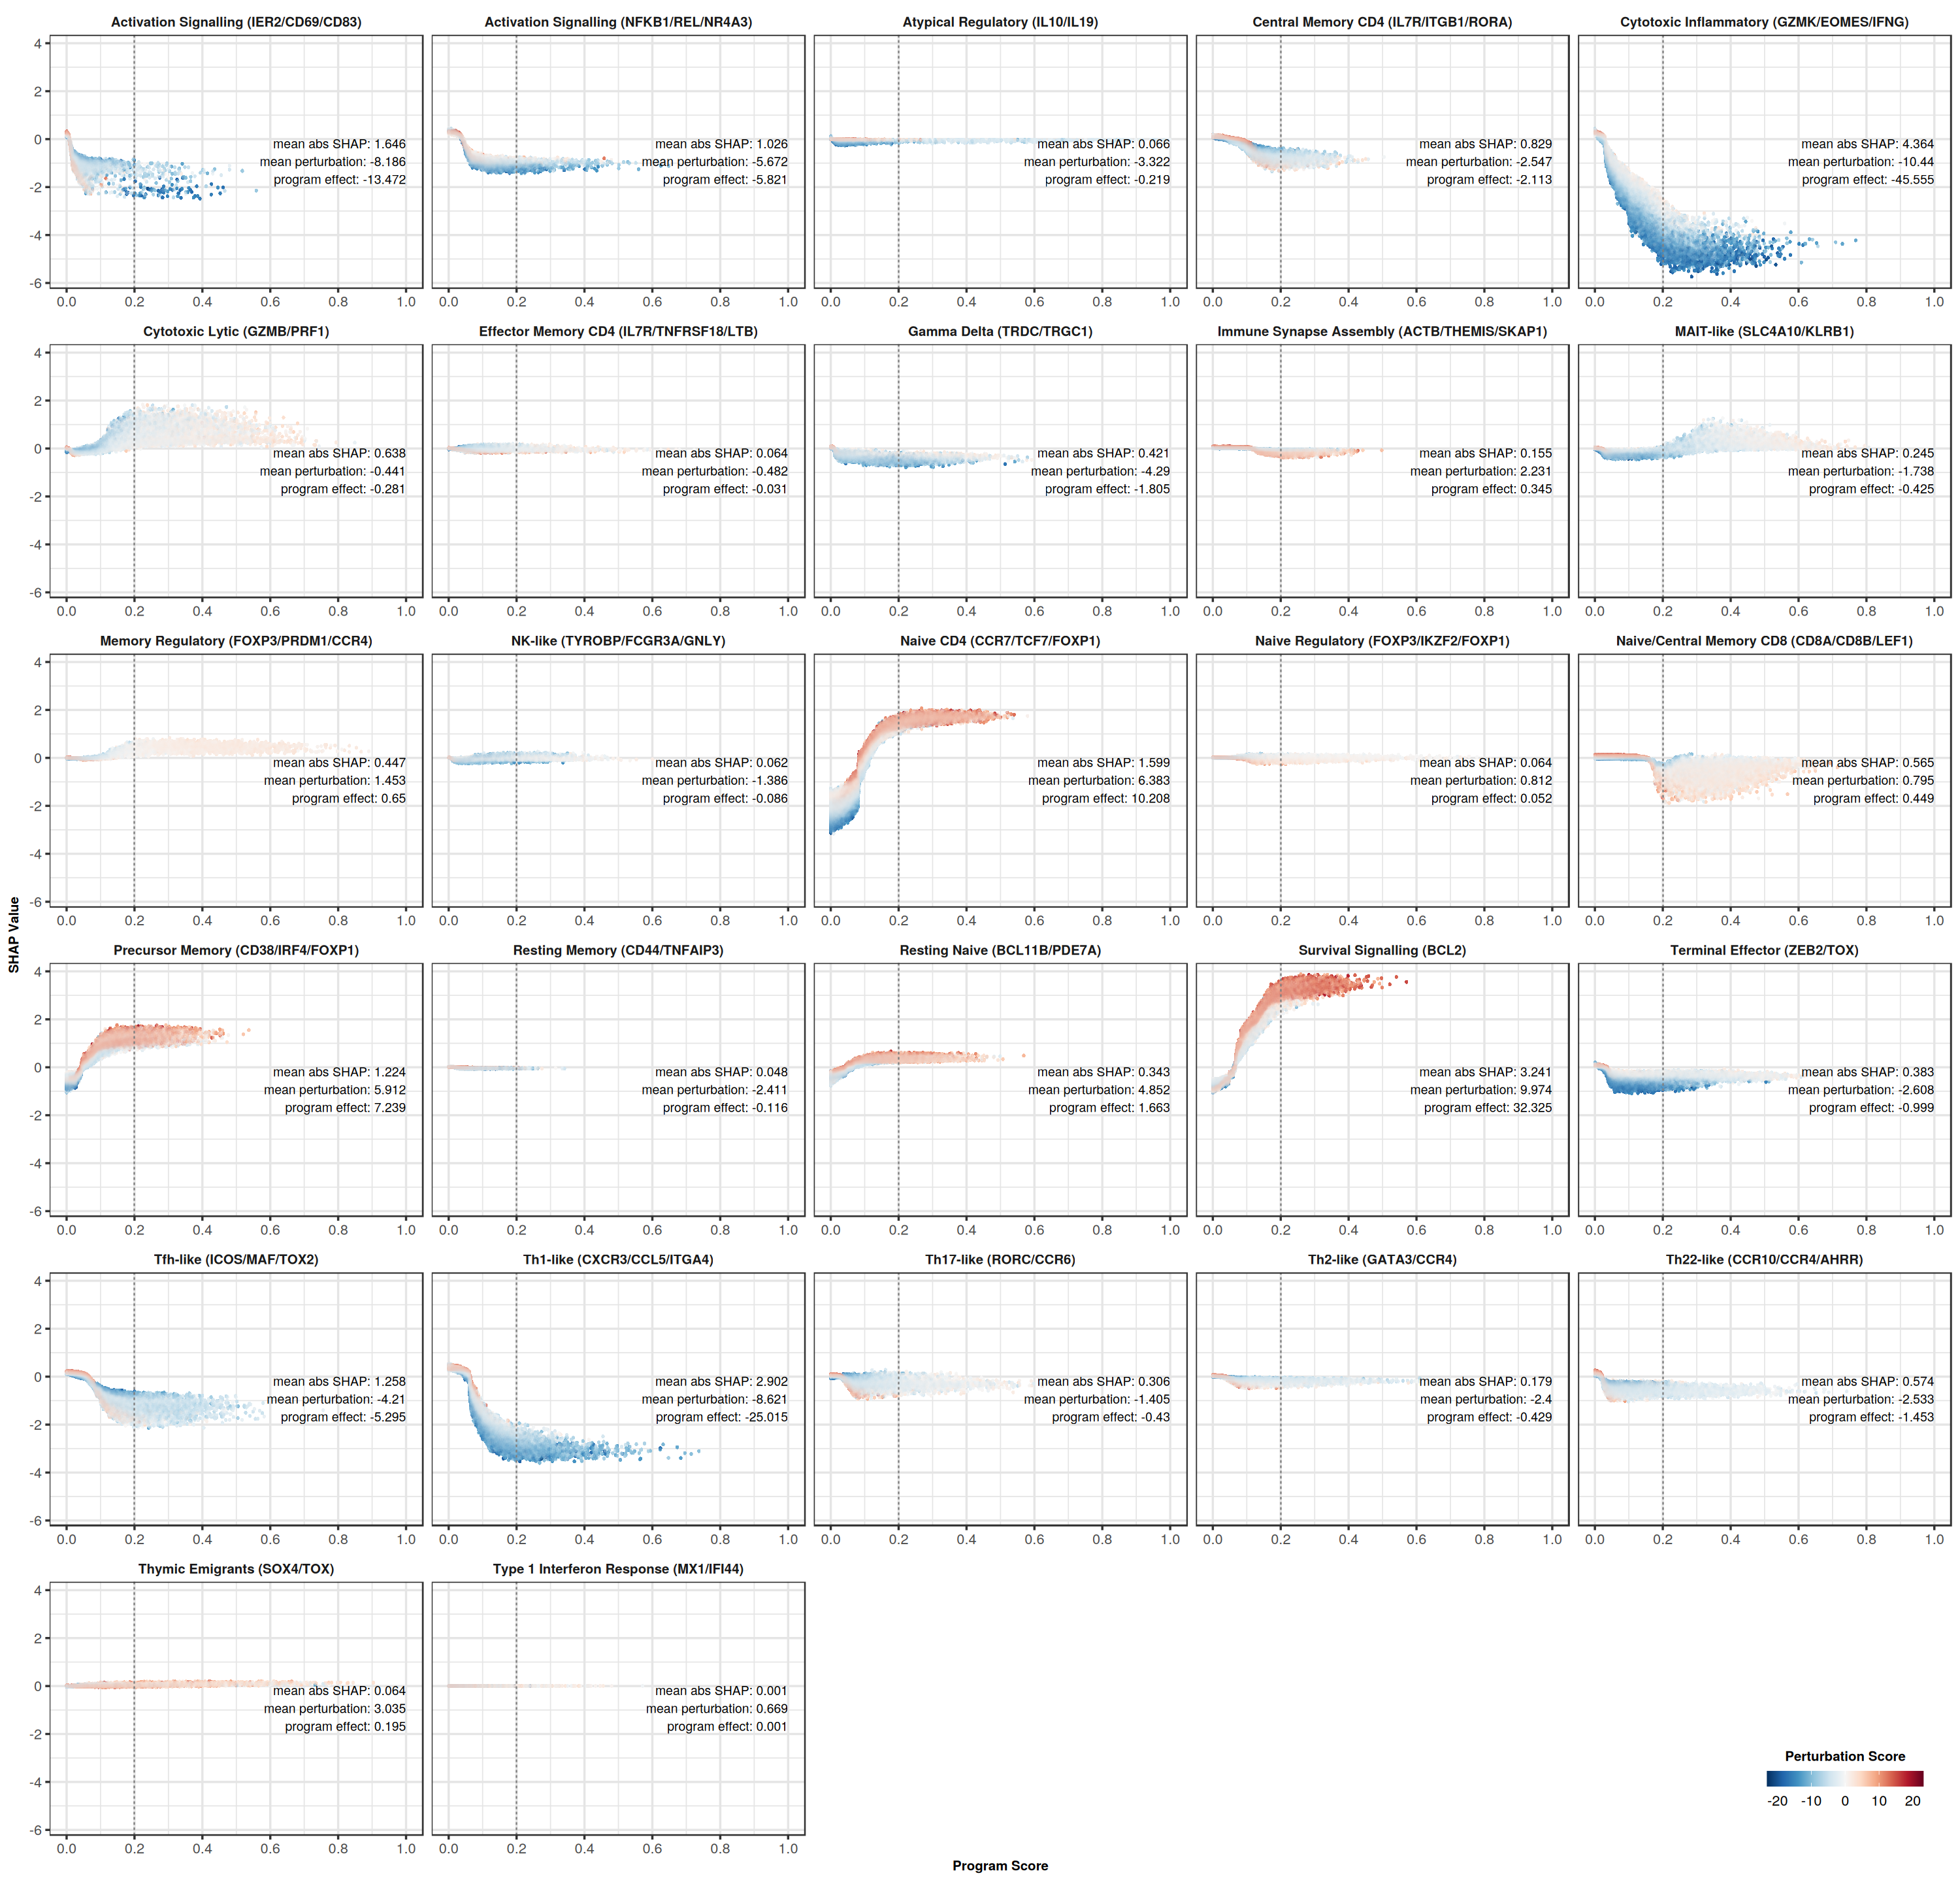

In [ ]:
options(repr.plot.width = 25, repr.plot.height = 24)

plot <- ggplot(data = data) +
  scattermore::geom_scattermore(mapping = aes(x = usage, y = shap_value, colour = z), pointsize = 10, alpha = 1, pixels = c(2048, 1229)) +
  geom_text(
    data = data.summary %>% mutate(label = paste0("mean abs SHAP: ", round(mean_abs_shap, 3), "\nmean perturbation: ", round(mean_perturbation, 3), "\nprogram effect: ", round(program_effect_score, 3))),
    mapping = aes(label = label),
    x = 1,
    y = 0,
    hjust = 1,
    vjust = 1,
    size = 4
  ) +
  geom_vline(xintercept = 0.2, linetype = "dashed", colour = "grey50") +
  scale_x_continuous(breaks = seq(0, 1, by = 0.2), limits = c(0, 1)) +
  scale_colour_gradientn(limits = max(abs(data$z)) * c(-1, 1), colours = rev(pals::brewer.rdbu(100))) +
  guides(colour = guide_colourbar(direction = "horizontal", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  facet_wrap(~program, ncol = 5, scales = "free_x") +
  labs(x = "Program Score", y = "SHAP Value", colour = "Perturbation Score") +
  theme_custom() +
  inset.legend(location = "bottomright") + 
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(size = 12, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 12, face = "bold"),
    strip.background = element_blank(),
    panel.grid = element_line(colour = "grey90")
  )

plot

ggsave(
  plot = plot,
  filename = glue::glue("../results/plots/cohort_treatment_naive_{cell.type}_{cond}_shap_program_perturbation.pdf"),
  width = 25,
  height = 24,
  units = "in",
  device = cairo_pdf
)

## Monocytes

In [ ]:
cell.type <- "Mono"
cond <- "Late"

usage.long <- gep.usage[[cell.type]] %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "usage")

shap.long <- shap[[cell.type]][[cond]] %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "shap_value")

meld <- meld.stats[[cond]] %>%
  rownames_to_column("barcode") %>%
  select(barcode, z)

data <- usage.long %>%
  full_join(shap.long, by = c("barcode", "program")) %>%
  left_join(meld, by = "barcode") %>%
  filter(!grepl(pattern = "Artefact|Contamination|Housekeeping", x = program))

In [ ]:
data.summary <- map_dfr(
  .x = unique(data$program),
  .f = function(x,
                threshold = 0.2) {
    I <- data %>% filter(program == x & usage > threshold)
    mean.abs.shap <- mean(abs(I$shap_value))
    mean.perturbation <- mean(I$z)
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
)

In [ ]:
data.summary

program,mean_abs_shap,mean_perturbation,program_effect_score
<chr>,<dbl>,<dbl>,<dbl>
Classical (S100A8/S100A9/VCAN),2.6365331,15.504514,40.878165
Homeostatic (ZBTB20/MEF2C/CLEC2D),0.7824594,10.395529,8.134079
Non-classical (FCGR3A/CX3CR1),4.7508307,1.307944,6.213822
Adhesion/Migration (CD44/VIM/EZR),0.6465469,12.808602,8.281362
Activation Signalling (IER2/FOS/JUN),7.7827813,1.944219,15.131428
Antigen Presentation (MHC-II/CD74),0.3637565,8.316530,3.025192
Adaptive Lipid Metabolism (PPARG/ABCA1),2.1542339,16.909087,36.426128
IL1Bhi Inflammatory (IL1B/CXCL8/CD83),3.7896606,19.898975,75.410360
Type 1 Interferon Response (MX1/IFI44),2.0568879,6.782500,13.950842


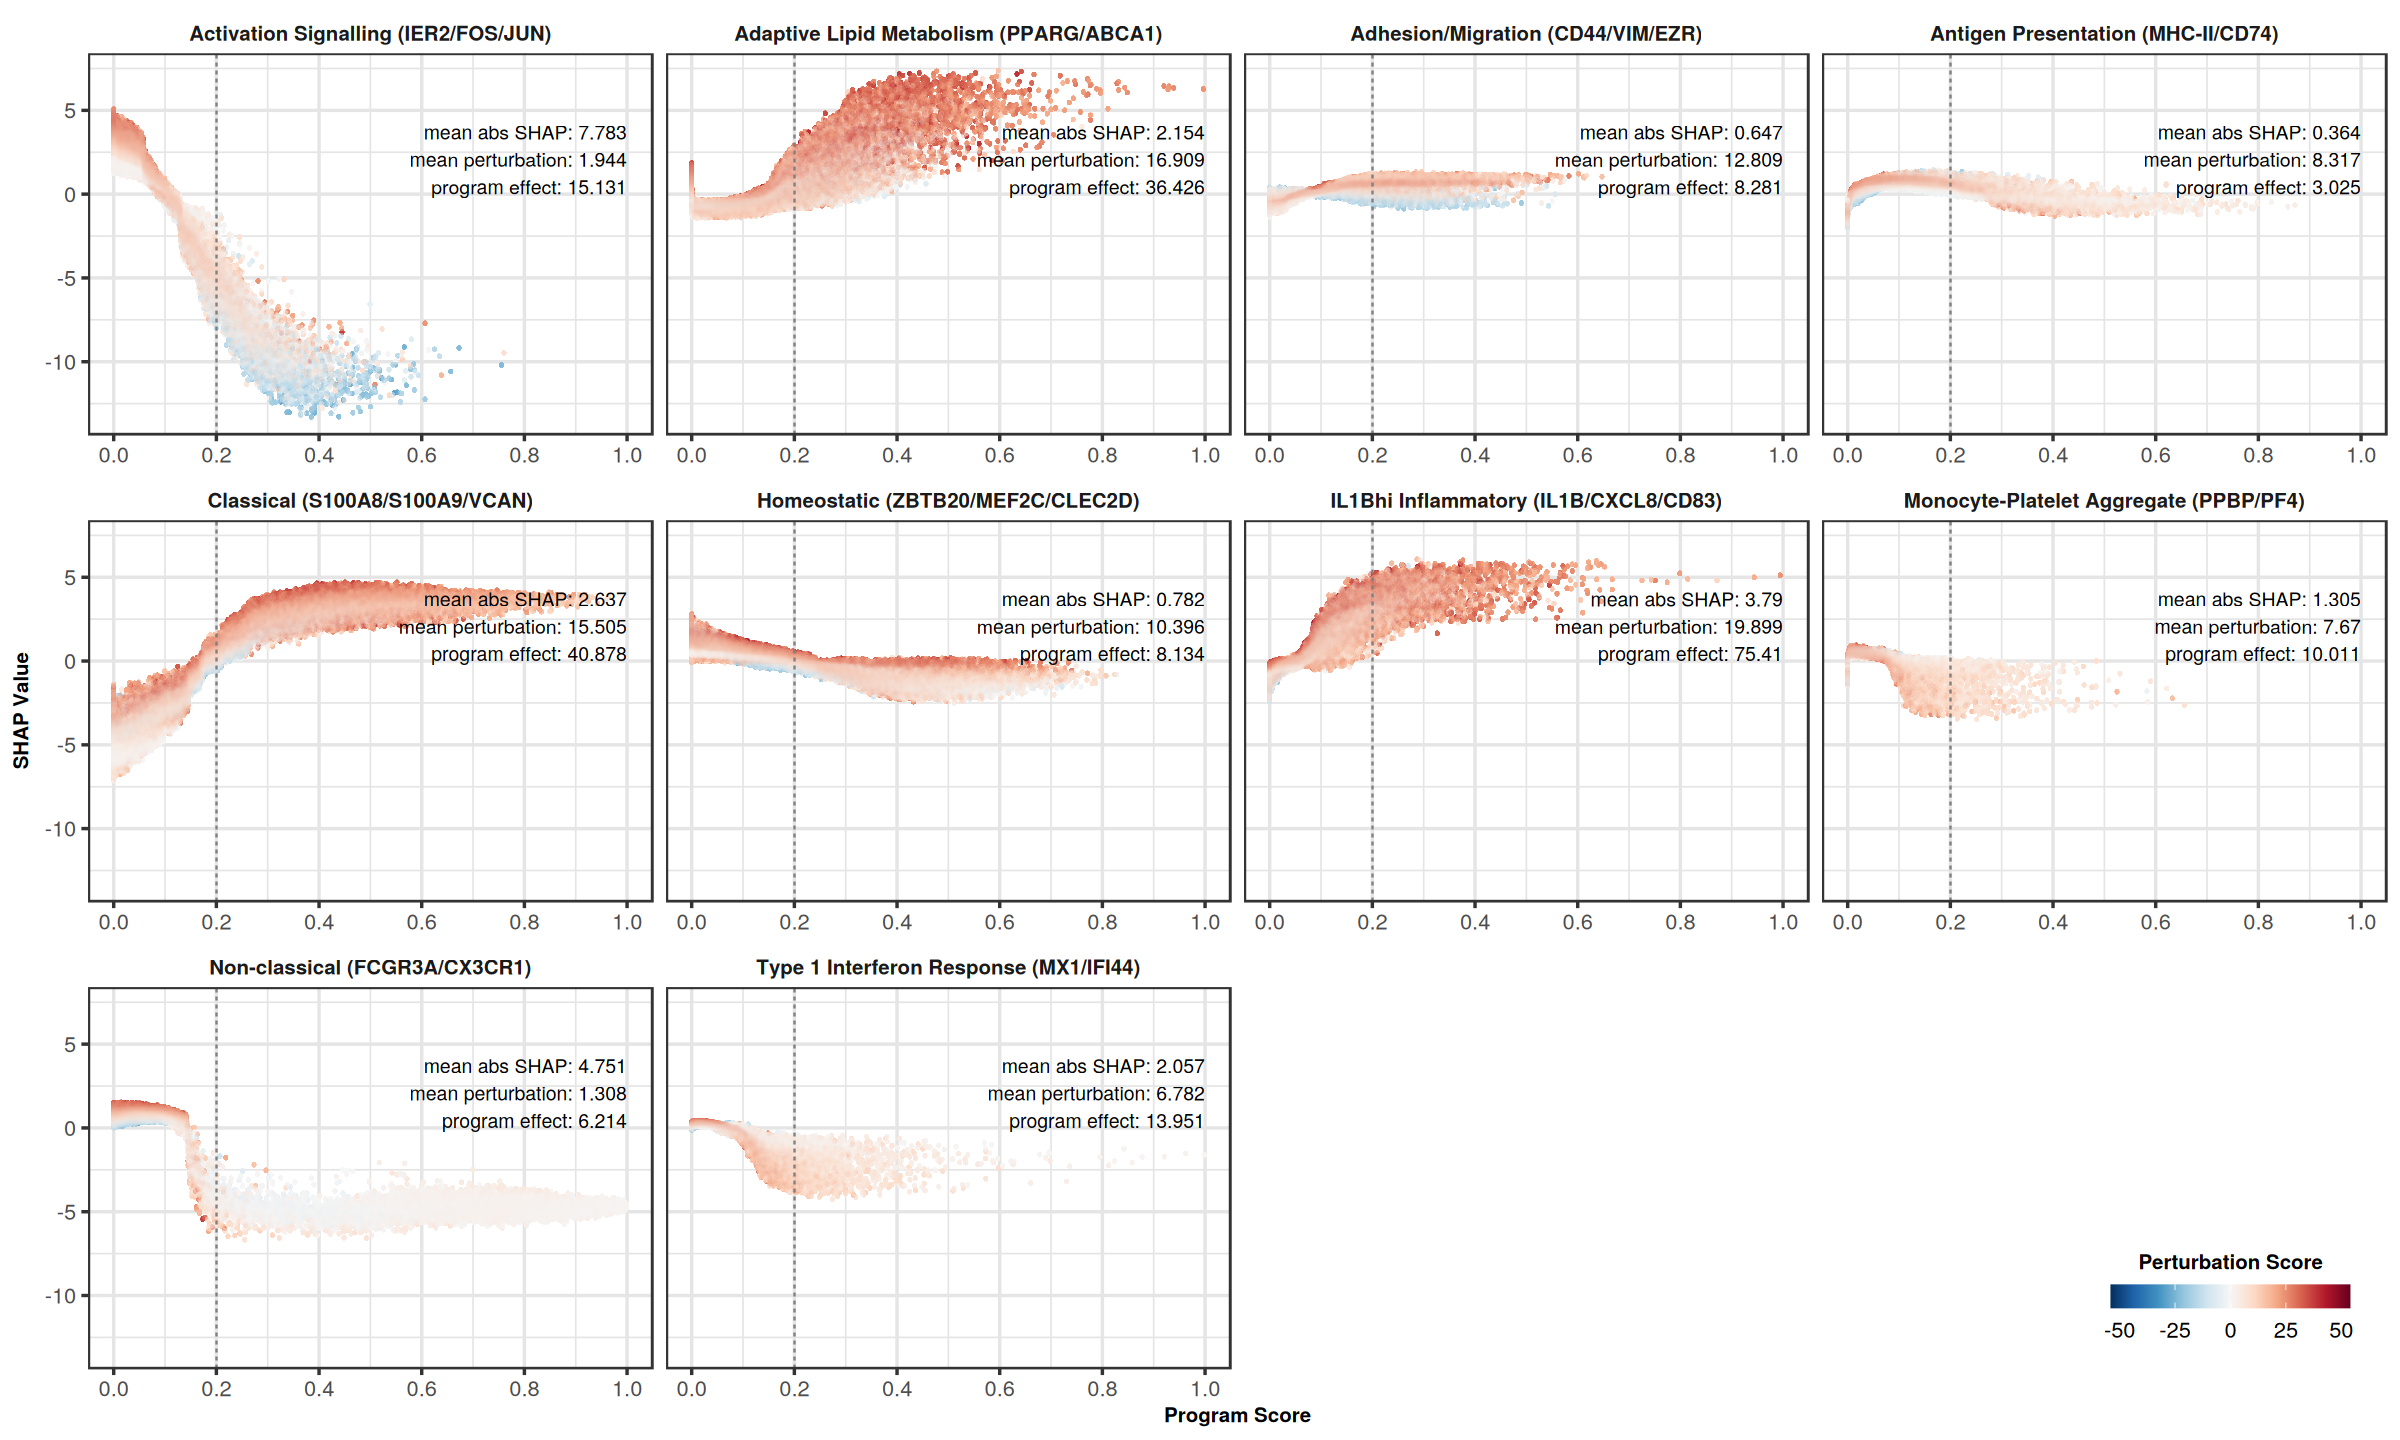

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 12)

plot <- ggplot(data = data) +
  scattermore::geom_scattermore(mapping = aes(x = usage, y = shap_value, colour = z), pointsize = 10, alpha = 1, pixels = c(2048, 1229)) +
  geom_text(
    data = data.summary %>% mutate(label = paste0("mean abs SHAP: ", round(mean_abs_shap, 3), "\nmean perturbation: ", round(mean_perturbation, 3), "\nprogram effect: ", round(program_effect_score, 3))),
    mapping = aes(label = label),
    x = 1,
    y = 0,
    hjust = 1,
    vjust = 0,
    size = 4
  ) +
  geom_vline(xintercept = 0.2, linetype = "dashed", colour = "grey50") +
  scale_x_continuous(breaks = seq(0, 1, by = 0.2), limits = c(0, 1)) +
  scale_colour_gradientn(limits = max(abs(data$z)) * c(-1, 1), colours = rev(pals::brewer.rdbu(100))) +
  guides(colour = guide_colourbar(direction = "horizontal", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  facet_wrap(~program, ncol = 4, scales = "free_x") +
  labs(x = "Program Score", y = "SHAP Value", colour = "Perturbation Score") +
  theme_custom() +
  inset.legend(location = "bottomright") + 
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(size = 12, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 12, face = "bold"),
    strip.background = element_blank(),
    panel.grid = element_line(colour = "grey90")
  )

plot

ggsave(
  plot = plot,
  filename = glue::glue("../results/plots/cohort_treatment_naive_{cell.type}_{cond}_shap_program_perturbation.pdf"),
  width = 20,
  height = 12,
  units = "in",
  device = cairo_pdf
)

# Natalizumab PBMC validation cohort

## Load data

### Perturbation scores

In [ ]:
meld.stats <- set_names(c("Post")) %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/external/kaufmann/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### GEP usages

In [ ]:
gep.usage <- set_names(c("B", "T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/external/kaufmann/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/external/kaufmann/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`


### SHAP values

In [ ]:
shap <- set_names(c("B", "T")) %>%
  map(
    .f = function(x) {
      set_names("Late") %>%
        map(
          .f = function(y) {
            mat <- read.table(
              file = glue::glue("../results/tables/external/kaufmann/shap/{x}/{y}.tsv"),
              sep = "\t",
              header = TRUE,
              row.names = 1,
              check.names = FALSE
            )
            return(mat)
          }
        )
    }
  )

## B cells

In [ ]:
cell.type <- "B"
cond <- "Post"

usage.long <- gep.usage[[cell.type]] %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "usage")

shap.long <- shap[[cell.type]][[cond]] %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "shap_value")

meld <- meld.stats[[cond]] %>%
  rownames_to_column("barcode") %>%
  select(barcode, z)

data <- usage.long %>%
  full_join(shap.long, by = c("barcode", "program")) %>%
  left_join(meld, by = "barcode") %>%
  filter(!grepl(pattern = "Artefact|Contamination|Housekeeping", x = program)) %>%
  drop_na()

In [ ]:
data.summary <- map_dfr(
  .x = unique(data$program),
  .f = function(x,
                threshold = 0.2) {
    I <- data %>% filter(program == x & usage > threshold)
    mean.abs.shap <- mean(abs(I$shap_value))
    mean.perturbation <- mean(I$z)
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
)

In [ ]:
data.summary

program,mean_abs_shap,mean_perturbation,program_effect_score
<chr>,<dbl>,<dbl>,<dbl>
Mature Naive (BACH2/SELL/IL4R),0.08823674,2.8288490,0.24960842
Homeostatic Memory (BANK1/AIM2/CD27),0.22727943,3.8365533,0.87196964
Survival Signalling (BCL2),0.01889456,3.0303095,0.05725635
Transitional Naive (MME/CD9/CD38),0.01851542,2.6333846,0.04875822
Primed Memory (IL2RA/TOX),0.10988430,3.9832458,0.43769618
Activated Memory (CD80/FAS),0.36318568,4.4714027,1.62394945
Activation Signalling (IER2/CD69/CD83),0.02026531,3.0448680,0.06170520
Atypical Memory (ITGAX/TBX21/FCRL5),0.01227233,3.5256005,0.04326735
IgA+ ASC (IGHA1/JCHAIN/MZB1),0.20602275,-1.2713873,-0.26193470


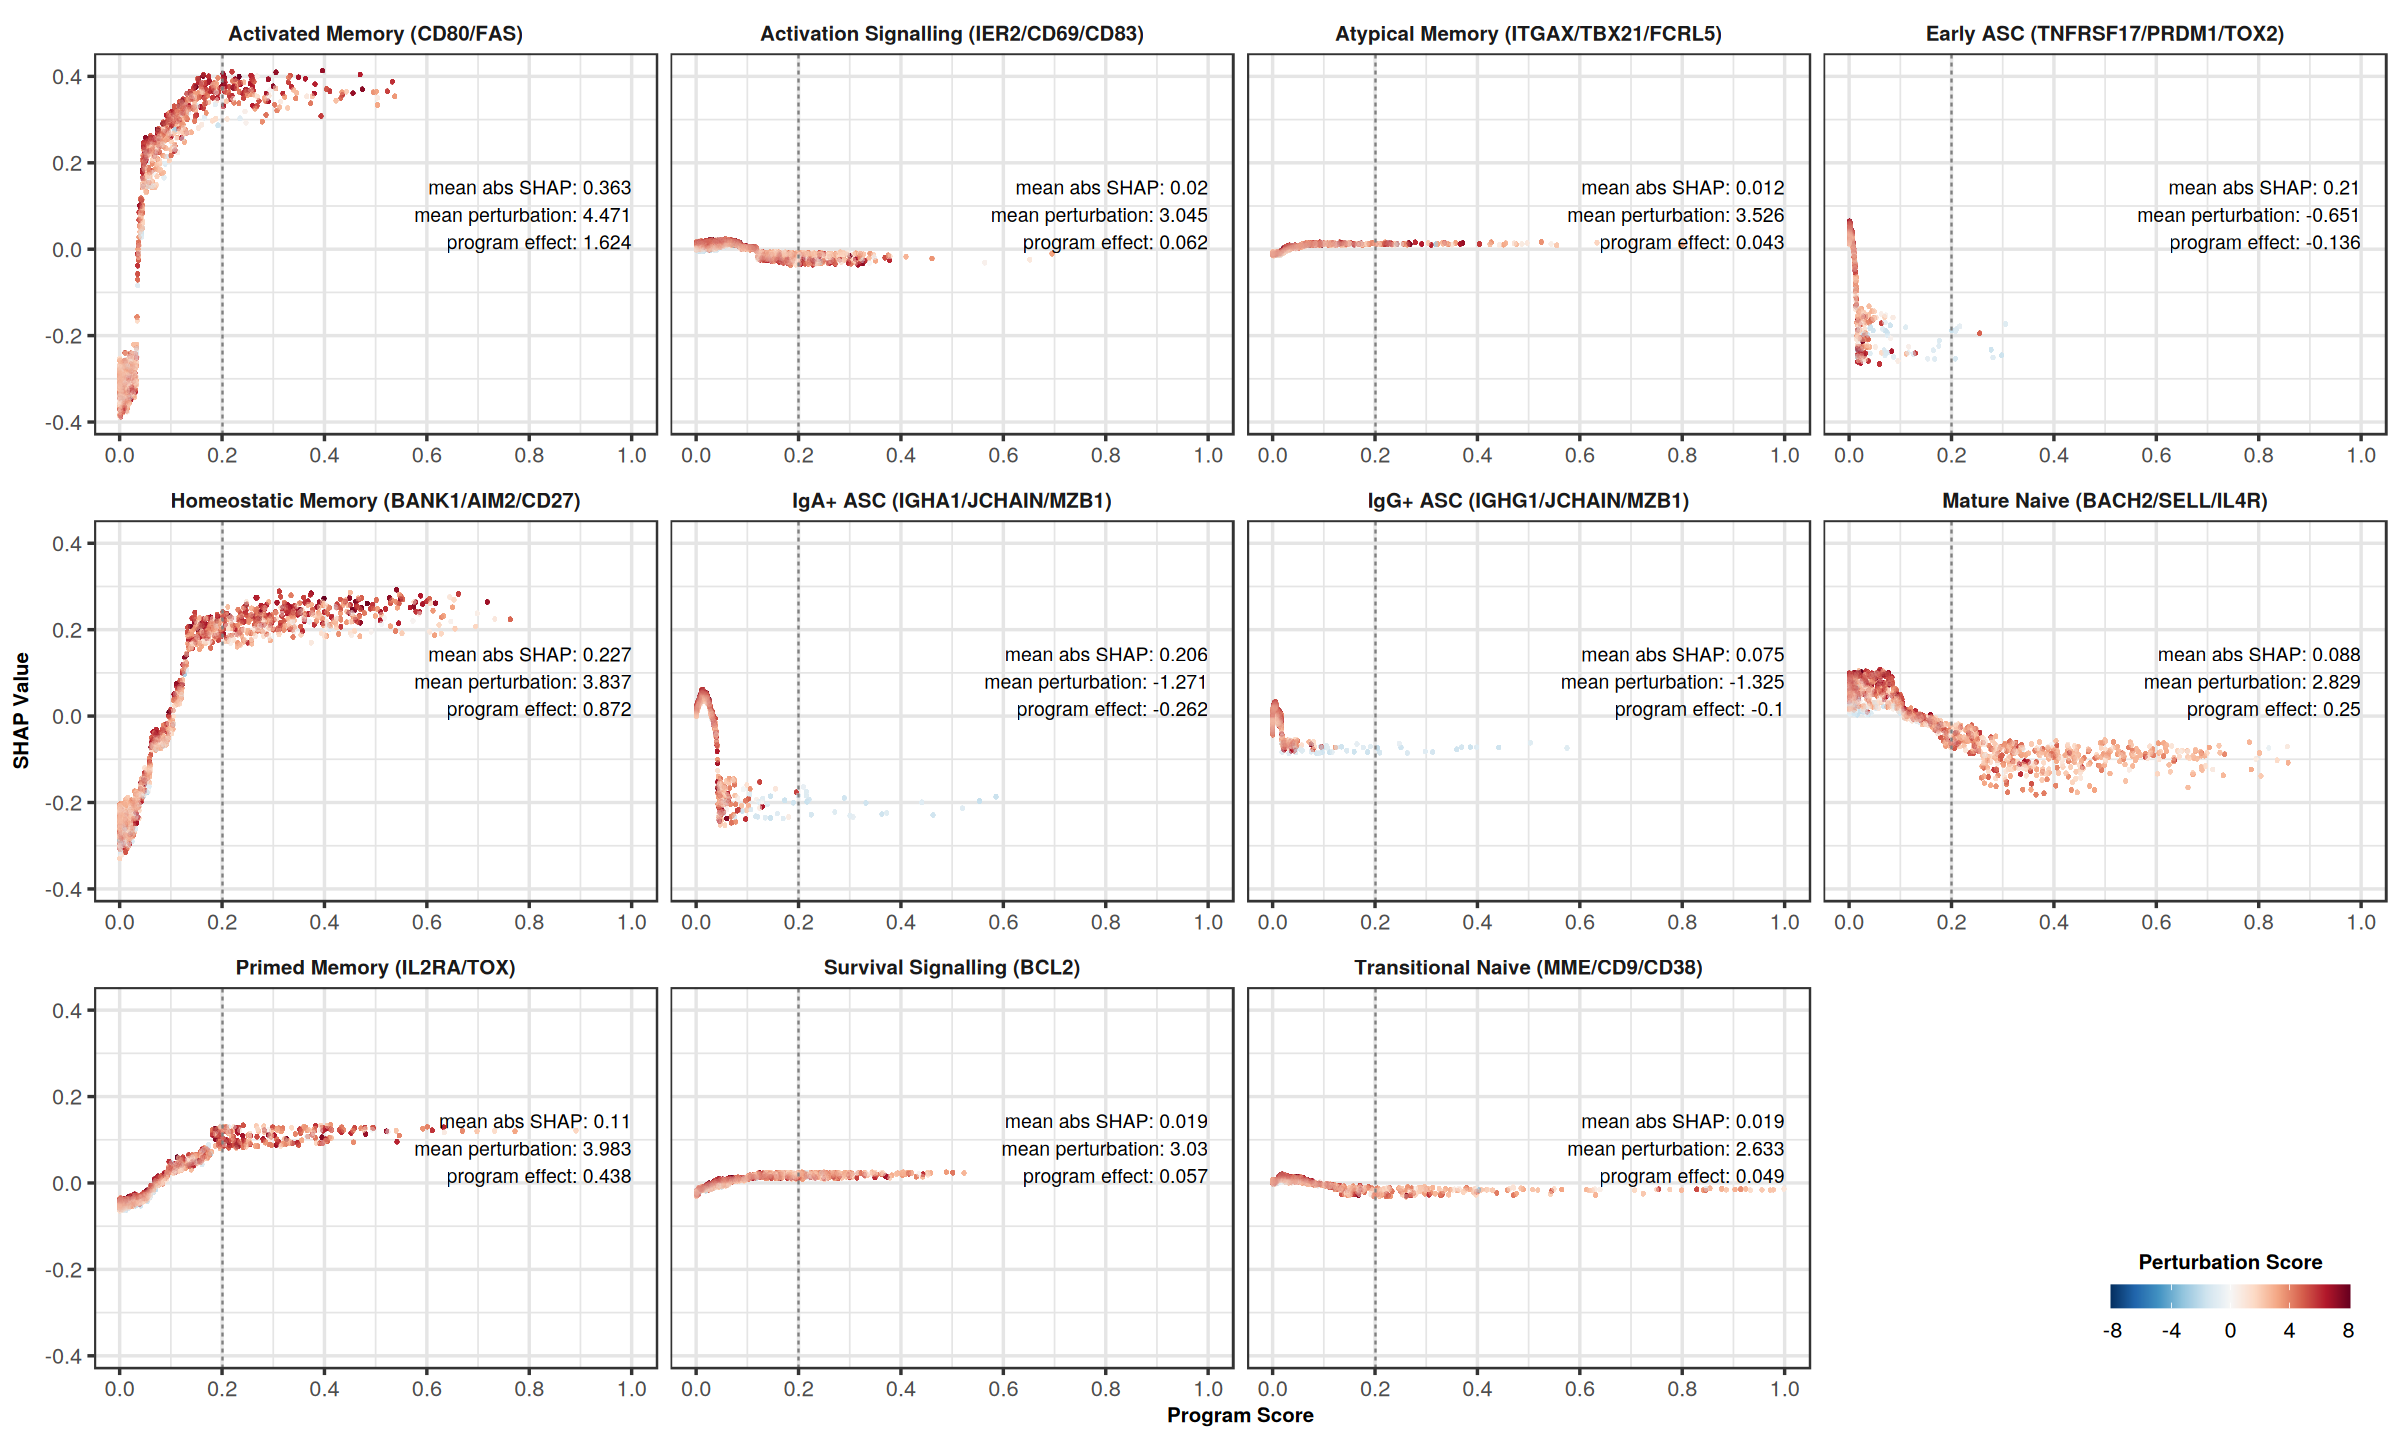

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 12)

plot <- ggplot(data = data) +
  scattermore::geom_scattermore(mapping = aes(x = usage, y = shap_value, colour = z), pointsize = 10, alpha = 1, pixels = c(2048, 1229)) +
  geom_text(
    data = data.summary %>% mutate(label = paste0("mean abs SHAP: ", round(mean_abs_shap, 3), "\nmean perturbation: ", round(mean_perturbation, 3), "\nprogram effect: ", round(program_effect_score, 3))),
    mapping = aes(label = label),
    x = 1,
    y = 0,
    hjust = 1,
    vjust = 0,
    size = 4
  ) +
  geom_vline(xintercept = 0.2, linetype = "dashed", colour = "grey50") +
  scale_x_continuous(breaks = seq(0, 1, by = 0.2), limits = c(0, 1)) +
  scale_colour_gradientn(limits = max(abs(data$z)) * c(-1, 1), colours = rev(pals::brewer.rdbu(100))) +
  guides(colour = guide_colourbar(direction = "horizontal", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  facet_wrap(~program, ncol = 4, scales = "free_x") +
  labs(x = "Program Score", y = "SHAP Value", colour = "Perturbation Score") +
  theme_custom() +
  inset.legend(location = "bottomright") + 
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(size = 12, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 12, face = "bold"),
    strip.background = element_blank(),
    panel.grid = element_line(colour = "grey90")
  )

plot

ggsave(
  plot = plot,
  filename = glue::glue("../results/plots/kaufmann_{cell.type}_{cond}_shap_program_perturbation.pdf"),
  width = 20,
  height = 12,
  units = "in",
  device = cairo_pdf
)

## T cells

In [ ]:
cell.type <- "T"
cond <- "Post"

usage.long <- gep.usage[[cell.type]] %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "usage")

shap.long <- shap[[cell.type]][[cond]] %>%
  as.data.frame() %>%
  rownames_to_column("barcode") %>%
  pivot_longer(cols = !barcode, names_to = "program", values_to = "shap_value")

meld <- meld.stats[[cond]] %>%
  rownames_to_column("barcode") %>%
  select(barcode, z)

data <- usage.long %>%
  full_join(shap.long, by = c("barcode", "program")) %>%
  left_join(meld, by = "barcode") %>%
  filter(!grepl(pattern = "Artefact|Contamination|Housekeeping", x = program)) %>%
  drop_na()

In [ ]:
data.summary <- map_dfr(
  .x = unique(data$program),
  .f = function(x,
                threshold = 0.2) {
    I <- data %>% filter(program == x & usage > threshold)
    mean.abs.shap <- mean(abs(I$shap_value))
    mean.perturbation <- mean(I$z)
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
)

In [ ]:
data.summary

program,mean_abs_shap,mean_perturbation,program_effect_score
<chr>,<dbl>,<dbl>,<dbl>
Naive CD4 (CCR7/TCF7/FOXP1),0.600175991,-0.01723211,-0.010342299
Immune Synapse Assembly (ACTB/THEMIS/SKAP1),0.033068431,1.88603785,0.062368312
Resting Naive (BCL11B/PDE7A),0.004660472,1.28983771,0.006011253
Naive/Central Memory CD8 (CD8A/CD8B/LEF1),0.476643550,-0.27104548,-0.129192079
Precursor Memory (CD38/IRF4/FOXP1),0.049046932,0.74126852,0.036356947
Survival Signalling (BCL2),0.007424796,1.05190710,0.007810196
Central Memory CD4 (IL7R/ITGB1/RORA),0.106629036,2.77152850,0.295525412
Activation Signalling (NFKB1/REL/NR4A3),2.128363559,-2.46829255,-5.253423922
Tfh-like (ICOS/MAF/TOX2),0.936990809,4.90041490,4.591643720


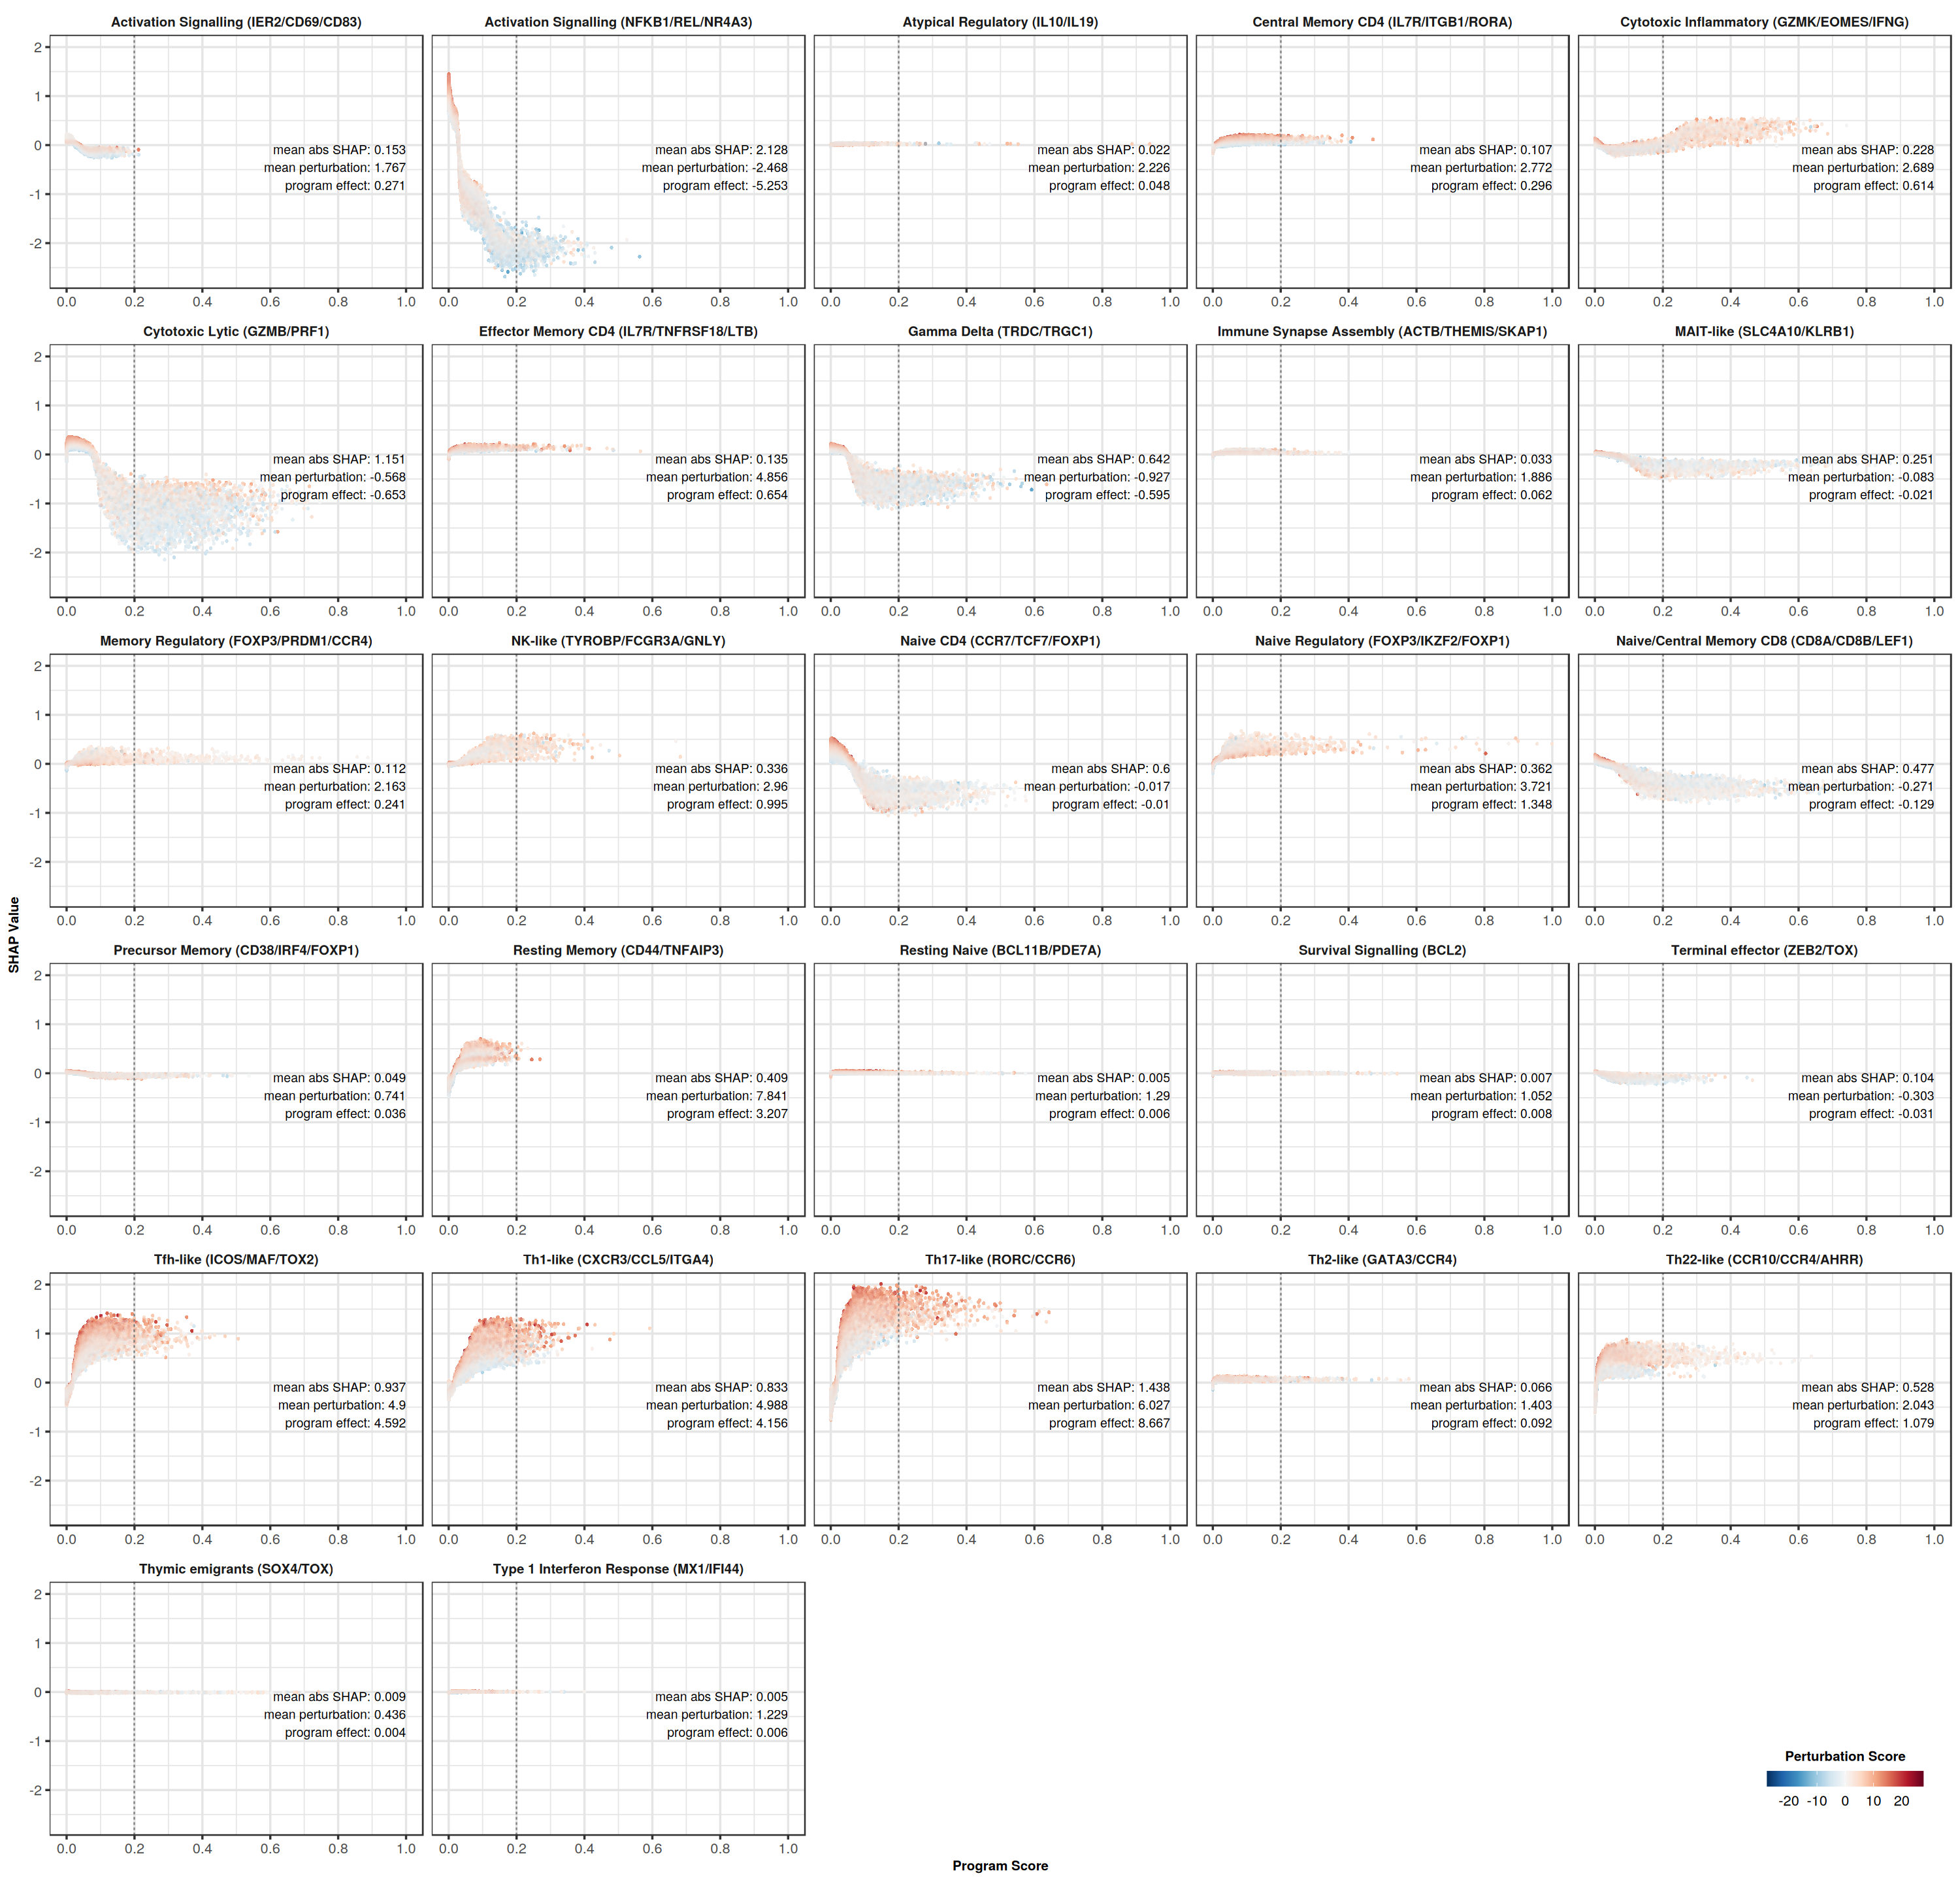

In [ ]:
options(repr.plot.width = 25, repr.plot.height = 24)

plot <- ggplot(data = data) +
  scattermore::geom_scattermore(mapping = aes(x = usage, y = shap_value, colour = z), pointsize = 10, alpha = 1, pixels = c(2048, 1229)) +
  geom_text(
    data = data.summary %>% mutate(label = paste0("mean abs SHAP: ", round(mean_abs_shap, 3), "\nmean perturbation: ", round(mean_perturbation, 3), "\nprogram effect: ", round(program_effect_score, 3))),
    mapping = aes(label = label),
    x = 1,
    y = 0,
    hjust = 1,
    vjust = 1,
    size = 4
  ) +
  geom_vline(xintercept = 0.2, linetype = "dashed", colour = "grey50") +
  scale_x_continuous(breaks = seq(0, 1, by = 0.2), limits = c(0, 1)) +
  scale_colour_gradientn(limits = max(abs(data$z)) * c(-1, 1), colours = rev(pals::brewer.rdbu(100))) +
  guides(colour = guide_colourbar(direction = "horizontal", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)) +
  facet_wrap(~program, ncol = 5, scales = "free_x") +
  labs(x = "Program Score", y = "SHAP Value", colour = "Perturbation Score") +
  theme_custom() +
  inset.legend(location = "bottomright") + 
  theme(
    legend.title.position = "top",
    legend.text.position = "bottom",
    legend.title = element_text(size = 12, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 12, face = "bold"),
    axis.title = element_text(size = 12, face = "bold"),
    strip.background = element_blank(),
    panel.grid = element_line(colour = "grey90")
  )

plot

ggsave(
  plot = plot,
  filename = glue::glue("../results/plots/kaufmann_{cell.type}_{cond}_shap_program_perturbation.pdf"),
  width = 25,
  height = 24,
  units = "in",
  device = cairo_pdf
)

# Session info

In [66]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4    
 [5] purrr_1.0.2     readr_2.1.5     tidyr_1.3.1     tibble_3.2.1   
 [9] ggplot2_3.5.1   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    stringi_1.8.4     hms_1.1.3        
 [5] digest_0.6.37     magrittr_2.0.3    evaluate_1.0.1    grid_4.3.3       
 [9] timechange_0.3.0  pbdZMQ_0.3-13     fastmap_1.2.0     maps_3.4.2       
[13] jsonlite_1.8.9    pals_1.9          scattermore_1.2   fansi_1.0.6      
[17] scales_1.3.0      cli_3.